# Chapter 4: Risk and Compliance — Credit Risk Fundamentals
**Financial AI in Practice** | Manning Publications

This notebook accompanies section 4.2.2, "Time-based performance and survival analysis," which treats default as a
trajectory rather than a single event. Listing 4.1 draws a vintage chart: one cumulative-default-rate curve per monthly
loan cohort, plotted against months on book, so cohorts can be compared at the same age and a cohort that deteriorates
faster than its predecessors stands out early. Listing 4.2 moves from cohort averages to individual loans: it simulates
50 loans (roughly 10% defaulting within 12 months, the rest censored) and fits a Kaplan–Meier survival curve with
`lifelines`. The book assumes you already have your own `vintage_data.csv`; because none ships with the book, the first
code cell writes a seeded, clearly synthetic stand-in with exactly the layout listing 4.1 expects.

## Synthetic `vintage_data.csv` (not a book listing)
**The data written by the next cell is synthetic.** It is not real loan performance data and not the data behind
figure 4.2; it only reproduces the layout described on p. 68, so that listing 4.1 runs as printed:

- index column `Vintage` with 21 monthly cohorts, `2022-04` to `2023-12`;
- columns `Month1` to `Month16`, each holding the cumulative default rate (%) at that month on book;
- months 1–3 are 0 (an account cannot be 90+ days past due before month 4), curves rise and level off around months
  10–12, and older cohorts settle higher (about 3.9%) than newer ones (about 1.3%), loosely mirroring figure 4.2;
- newer cohorts are right-censored at a 2024-04 snapshot (`2023-12` has only 4 months on book), so their later cells
  are blank, which is the case the `errors='coerce'` conversion in listing 4.1 handles.

The generator is seeded (`np.random.default_rng(42)`), so it always writes the same file. If `vintage_data.csv`
already exists (for example, your own data in the same layout), it is left untouched.

In [1]:
# Synthetic stand-in for vintage_data.csv -- NOT a book listing and NOT real loan data.
# Writes the layout that listing 4.1 expects (p. 68): index column "Vintage" plus
# Month1..Month16, each cell = cumulative default rate (%) at that month on book.
from pathlib import Path

import numpy as np
import pandas as pd

csv_path = Path("vintage_data.csv")

if csv_path.exists():
    print(f"{csv_path} already exists; leaving it unchanged (delete it to regenerate the synthetic data).")
else:
    rng = np.random.default_rng(42)
    vintages = pd.period_range("2022-04", "2023-12", freq="M")  # 21 monthly cohorts
    snapshot = pd.Period("2024-04", freq="M")                    # data cut-off date
    months_on_book = np.arange(1, 17)                             # 1..16

    rows = {}
    for i, vintage in enumerate(vintages):
        # Older cohorts settle higher (~3.9%) than newer ones (~1.3%), loosely like figure 4.2.
        final_rate = 3.9 - 2.6 * i / (len(vintages) - 1) + rng.normal(0, 0.1)
        speed = rng.normal(4.0, 0.3)
        # Nothing can be 90+ days past due before month 4; defaults then build up and level off.
        t = np.clip(months_on_book - 3, 0, None)
        curve = np.round(final_rate * (1 - np.exp(-(t / speed) ** 1.4)), 2)
        # Months not yet observed at the snapshot stay blank (right-censored, newer cohorts).
        observed = min(len(months_on_book), (snapshot - vintage).n)
        curve[observed:] = np.nan
        rows[str(vintage)] = curve

    synthetic = pd.DataFrame.from_dict(rows, orient="index",
                                       columns=[f"Month{m}" for m in months_on_book])
    synthetic.index.name = "Vintage"
    synthetic.to_csv(csv_path)
    print(f"Wrote SYNTHETIC {csv_path}: {len(synthetic)} vintages x {synthetic.shape[1]} month columns.")

# Oldest two and newest two cohorts (blank cells = not yet observed)
pd.read_csv(csv_path, index_col="Vintage").iloc[[0, 1, -2, -1]]

Wrote SYNTHETIC vintage_data.csv: 21 vintages x 16 month columns.


,Month1,Month2,Month3,Month4,Month5,Month6,Month7,Month8,Month9,Month10,Month11,Month12,Month13,Month14,Month15,Month16
Vintage,,,,,,,,,,,,,,,,
2022-04,0.0,0.0,0.0,0.58,1.36,2.07,2.65,3.08,3.39,3.59,3.73,3.81,3.86,3.89,3.91,3.92
2022-05,0.0,0.0,0.0,0.47,1.12,1.75,2.30,2.73,3.07,3.32,3.50,3.62,3.70,3.75,3.79,3.81
2023-11,0.0,0.0,0.0,0.17,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12,0.0,0.0,0.0,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Listing 4.1 — Vintage analysis
*Section 4.2.2, Vintage analysis (p. 68; the book's output is figure 4.2)*

Loads `vintage_data.csv` from this folder and plots each vintage's cumulative default curve.

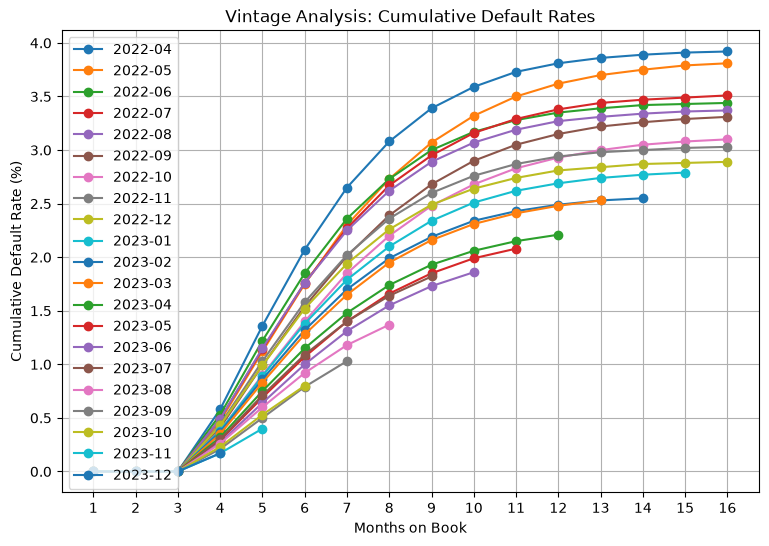

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the CSV, using "Vintage" as the index
df_loaded = pd.read_csv("vintage_data.csv", index_col="Vintage")

# Step 2: Plot each vintage as a line
plt.figure(figsize=(9,6))
months = range(1, 17)  # for 16 months on book

for vintage in df_loaded.index:
    # Convert each row to numeric in case of missing cells
    row_values = pd.to_numeric(df_loaded.loc[vintage], errors='coerce')
    plt.plot(months, row_values, marker='o', label=vintage)

plt.title("Vintage Analysis: Cumulative Default Rates")
plt.xlabel("Months on Book")
plt.ylabel("Cumulative Default Rate (%)")
plt.xticks(months)
plt.grid(True)
plt.legend(loc='upper left')
plt.show()

### Listing 4.2 — Survival analysis example [4]
*Section 4.2.2, Survival analysis: Beyond "cohort averages" (p. 70; the book's output is figure 4.3)*

Generates its own synthetic loans, so it needs no data file. The book's margin notes on this listing:

- `r = np.random.rand()`: generates a random float `r` for each synthetic loan, deciding if it defaults (~10% chance)
  or survives.
- `if r < 0.1:`: if `r < 0.1`, mark this loan as defaulting; otherwise, it's considered "current."
- `event_observed.append(1)`: a value of 1 in `event_observed` indicates a default event.
- `event_observed.append(0)`: a 0 indicates the loan is censored (never defaulted) by month 12.
- `kmf = KaplanMeierFitter()`: creates a Kaplan–Meier fitter from the `lifelines` library, which calculates the
  survival function.
- `kmf.plot_survival_function()`: plots the resulting survival curve, showing the probability a loan remains "not
  defaulted" through each month.

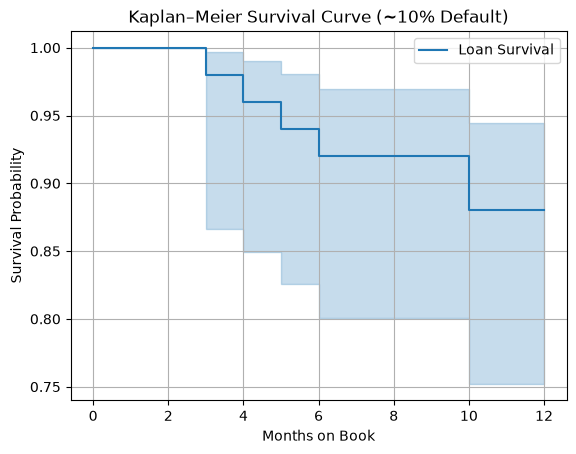

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

np.random.seed(42)

# Generate 50 synthetic loans with ~10% default by 12 months
N = 50
time_to_default = []
event_observed = []

for _ in range(N):
    r = np.random.rand()
    if r < 0.1:
        possible_months = [3,4,5,6,7,8,9,10]
        d_month = np.random.choice(possible_months)
        time_to_default.append(d_month)
        event_observed.append(1)
    else:
        time_to_default.append(12)
        event_observed.append(0)

df_surv = pd.DataFrame({
    "loan_id": range(1, N+1),
    "time_to_default": time_to_default,
    "event_observed": event_observed
})

# Fit the Kaplan–Meier model
kmf = KaplanMeierFitter()
kmf.fit(
    durations=df_surv["time_to_default"],
    event_observed=df_surv["event_observed"],
    label="Loan Survival"
)

# Plot the KM survival function
kmf.plot_survival_function()
plt.title("Kaplan–Meier Survival Curve (~10% Default)")
plt.xlabel("Months on Book")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()